In [1]:
# Imports
from kymotools.utils import fileutils

import csv
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Parameters
filepath = './examples/input/'
filename = 'Photobleaching steps_red and green channels.csv'
heatmap_width = 4
heatmap_height = 4

In [3]:
# File loading
with open(filepath+filename, newline='') as f:
    reader = csv.reader(f)
    data = list(reader)

In [4]:
# Creating heatmap image
arr = np.asarray(data)
heatmap = np.zeros((heatmap_height,heatmap_width))

for row in arr:
    r = min(row[0].astype(np.uint8),heatmap_height-1)
    c = min(row[1].astype(np.uint8),heatmap_width-1)

    heatmap[r,c] = heatmap[r,c] + 1

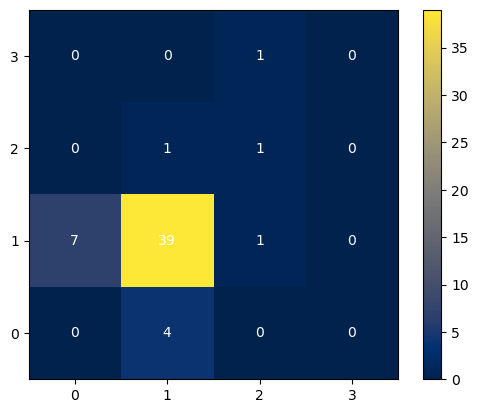

In [5]:
# Adding axes and saving
fig = plt.figure()
im_plt = plt.imshow(heatmap)
ax = plt.gca()
ax.invert_yaxis()
ax.set_xticks(range(heatmap_width))
ax.set_yticks(range(heatmap_height))
plt.set_cmap('cividis')
cbar = ax.figure.colorbar(im_plt, ax=ax)

for i in range(heatmap_height):
    for j in range(heatmap_width):
        text = ax.text(j, i, heatmap[i, j].astype(np.uint16), ha="center", va="center", color="w")

plt.savefig(filepath+fileutils.strip_ext(filename)+"_heatmap.svg")
plt.savefig(filepath+fileutils.strip_ext(filename)+"_heatmap.png")